# Assignment 23 — Data Wrangling on Academic Performance Dataset

## Topic Explanation

**Data Wrangling** (also called *data cleaning* or *data munging*) is the process of taking raw, messy, real-world data and transforming it into a clean, structured form ready for analysis. It typically takes **60–80% of the total time** in a data-science project. The famous saying: **"garbage in, garbage out"** — even the best ML algorithm fails on dirty data.

### About the Academic Performance Dataset
A synthetic dataset of 50 students containing:

| Column | Meaning |
|--------|---------|
| `Roll_No` | Student ID |
| `Name` | Student name |
| `Gender` | Gender (often inconsistent: M/Male/male/MALE, F/Female/female/FEMALE) |
| `Age` | Age in years |
| `Class` | Year level (FY, SY, TY, BE) |
| `Math_Score` | Math test score (0–100) |
| `Reading_Score` | Reading test score (0–100) |
| `Writing_Score` | Writing test score (0–100) |
| `Placement_Score` | Campus placement assessment score (0–100) |
| `Attendance` | Attendance percentage (0–100) |
| `Study_Hours` | Daily study hours |

This dataset deliberately contains real-world messiness: missing values, inconsistent gender labels, out-of-range values (negative ages, attendance > 100%), and skewed distributions.

### Three Operations We'll Perform

#### 1. Missing Values & Inconsistencies
- **Missing values** are NaN cells — we fill them with the column **median** (robust to outliers)
- **Inconsistencies** include:
  - Gender labels written 8 different ways (M, Male, male, MALE, F, Female, female, FEMALE)
  - Out-of-range values (Age = -3, Age = 150, Attendance = 110%, scores > 100)
  - We detect them, replace with NaN, then impute

#### 2. Outliers
We detect outliers using the **IQR rule**:
- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- Outlier if value < Q1 − 1.5·IQR or > Q3 + 1.5·IQR

We treat them via **winsorization (capping)** — replacing extreme values with the boundary instead of removing rows.

#### 3. Data Transformation
We apply a **log transformation** to `Study_Hours` because study time tends to be **right-skewed** — most students study moderately, but a few study very long hours, pulling the mean upward. Log transformation reduces this skewness.

## Step 1: Import Libraries

In [1]:
# pandas — DataFrame operations
import pandas as pd

# numpy — numerical operations; provides np.nan and mathematical functions like log1p
import numpy as np

# matplotlib & seaborn — visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline in the notebook
%matplotlib inline
sns.set_style('whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load the Dataset

In [2]:
# read_csv() loads a CSV into a pandas DataFrame
df = pd.read_csv('academic_performance.csv')
print("Shape:", df.shape)
df.head()

Shape: (50, 11)


,Roll_No,Name,Gender,Age,Class,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours
0,1,Student_001,M,20.0,TY,78.8,77.3,51.8,9.6,84.8,4.57
1,2,Student_002,Female,20.0,SY,69.4,77.8,89.1,39.6,76.2,8.12
2,3,Student_003,male,18.0,TY,45.4,80.1,71.7,42.9,105.0,1.36
3,4,Student_004,FEMALE,19.0,BE,NaN,82.4,76.2,37.6,64.1,5.16
4,5,Student_005,FEMALE,18.0,TY,54.0,55.7,66.1,21.5,67.9,5.90


In [3]:
# info() — column names, non-null counts, data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Roll_No          50 non-null     int64  
 1   Name             50 non-null     str    
 2   Gender           50 non-null     str    
 3   Age              50 non-null     float64
 4   Class            50 non-null     str    
 5   Math_Score       49 non-null     float64
 6   Reading_Score    49 non-null     float64
 7   Writing_Score    50 non-null     float64
 8   Placement_Score  49 non-null     float64
 9   Attendance       49 non-null     float64
 10  Study_Hours      50 non-null     float64
dtypes: float64(7), int64(1), str(3)
memory usage: 4.4 KB


In [4]:
# describe() — summary statistics
# Watch the min/max values — anything out of range is a red flag
df.describe()

,Roll_No,Age,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours
count,50.00000,50.000000,49.000000,49.000000,50.000000,49.000000,49.000000,50.000000
mean,25.50000,21.320000,69.916327,70.404082,70.084000,37.136735,78.865306,6.588000
std,14.57738,18.899779,14.076256,11.804659,15.947661,25.506230,11.758872,7.823478
min,1.00000,-3.000000,41.700000,49.200000,30.600000,6.100000,60.100000,0.800000
25%,13.25000,18.000000,60.800000,61.300000,58.225000,16.200000,70.700000,2.842500
50%,25.50000,19.000000,71.100000,69.500000,69.600000,29.500000,76.900000,4.635000
75%,37.75000,20.000000,79.700000,80.600000,80.850000,51.300000,88.000000,6.892500
max,50.00000,150.000000,105.000000,96.000000,98.900000,91.100000,110.000000,42.000000


## Operation 1 — Missing Values & Inconsistencies

We tackle this in two parts:
- **3.1 Missing values** — empty cells (NaN)
- **3.2 Inconsistencies** — values that exist but are invalid (wrong format or out of range)

### 3.1 Detect Missing Values

In [5]:
# isnull() returns True for every NaN; .sum() counts them per column
print("Missing values per column:")
print(df.isnull().sum())

print("\nTotal missing cells:", df.isnull().sum().sum())

Missing values per column:
Roll_No            0
Name               0
Gender             0
Age                0
Class              0
Math_Score         1
Reading_Score      1
Writing_Score      0
Placement_Score    1
Attendance         1
Study_Hours        0
dtype: int64

Total missing cells: 4


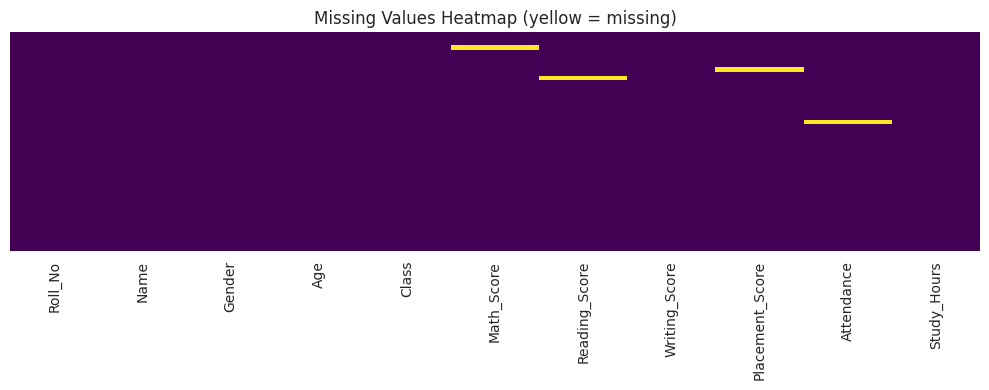

In [6]:
# Visualize missing values as a heatmap — yellow stripes mark NaN cells
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

### 3.2 Detect Inconsistent Gender Values

In [7]:
# Show the variety of gender labels currently present
print("Unique Gender values BEFORE cleaning:")
print(df['Gender'].unique())

print("\nValue counts:")
print(df['Gender'].value_counts())

Unique Gender values BEFORE cleaning:
<StringArray>
['M', 'Female', 'male', 'FEMALE', 'female', 'F', 'MALE', 'Male']
Length: 8, dtype: str

Value counts:


Gender
FEMALE    11
MALE       9
F          8
female     6
male       5
Female     4
Male       4
M          3
Name: count, dtype: int64


### 3.3 Standardize Gender Labels

In [8]:
# Step 1: strip whitespace
# Step 2: lowercase
# Step 3: map all variants to clean labels
df['Gender'] = (df['Gender']
                .str.strip()
                .str.lower()
                .map({'m': 'Male', 'male': 'Male',
                      'f': 'Female', 'female': 'Female'}))

print("Unique Gender values AFTER cleaning:")
print(df['Gender'].unique())
print("\nValue counts:")
print(df['Gender'].value_counts())

Unique Gender values AFTER cleaning:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Value counts:
Gender
Female    29
Male      21
Name: count, dtype: int64


### 3.4 Detect Out-of-Range (Invalid) Numeric Values

In [9]:
# Define plausible ranges
print("Invalid Age values (< 15 or > 30):")
print(df[(df['Age'] < 15) | (df['Age'] > 30)][['Roll_No', 'Name', 'Age']])

print("\nInvalid Attendance values (> 100 or < 0):")
print(df[(df['Attendance'] > 100) | (df['Attendance'] < 0)][['Roll_No', 'Name', 'Attendance']])

# Check score columns too
score_cols = ['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score']
for col in score_cols:
    invalid = df[(df[col] > 100) | (df[col] < 0)]
    if not invalid.empty:
        print(f"\nInvalid {col} values (> 100 or < 0):")
        print(invalid[['Roll_No', 'Name', col]])

Invalid Age values (< 15 or > 30):
    Roll_No         Name    Age
5         6  Student_006   -3.0
12       13  Student_013  150.0

Invalid Attendance values (> 100 or < 0):
    Roll_No         Name  Attendance
2         3  Student_003       105.0
15       16  Student_016       110.0

Invalid Math_Score values (> 100 or < 0):
   Roll_No         Name  Math_Score
7        8  Student_008       105.0


### 3.5 Replace Invalid Values with NaN, Then Impute

In [10]:
# Mark out-of-range values as NaN so they get imputed like any other missing data
df.loc[(df['Age'] < 15) | (df['Age'] > 30), 'Age'] = np.nan
df.loc[(df['Attendance'] > 100) | (df['Attendance'] < 0), 'Attendance'] = np.nan

for col in ['Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score']:
    df.loc[(df[col] < 0) | (df[col] > 100), col] = np.nan

print("Missing values after flagging invalid entries:")
print(df.isnull().sum())

Missing values after flagging invalid entries:
Roll_No            0
Name               0
Gender             0
Age                2
Class              0
Math_Score         2
Reading_Score      1
Writing_Score      0
Placement_Score    1
Attendance         3
Study_Hours        0
dtype: int64


In [11]:
# Fill all numeric NaN values with the column MEDIAN (robust to outliers)
# Use assignment style (not inplace=True) to avoid pandas Copy-on-Write issues
for col in df.select_dtypes(include='number').columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after imputation:", df.isnull().sum().sum())
df.head()

Missing values after imputation: 0


,Roll_No,Name,Gender,Age,Class,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours
0,1,Student_001,Male,20.0,TY,78.80,77.3,51.8,9.6,84.8,4.57
1,2,Student_002,Female,20.0,SY,69.40,77.8,89.1,39.6,76.2,8.12
2,3,Student_003,Male,18.0,TY,45.40,80.1,71.7,42.9,76.7,1.36
3,4,Student_004,Female,19.0,BE,70.75,82.4,76.2,37.6,64.1,5.16
4,5,Student_005,Female,18.0,TY,54.00,55.7,66.1,21.5,67.9,5.90


## Operation 2 — Outlier Detection & Treatment

An **outlier** is a value far from the rest of the data. We:
1. Visualize using **boxplots**
2. Detect numerically using the **IQR rule**
3. Treat by **capping (winsorization)**

### 4.1 Visualize Outliers — Boxplots BEFORE Treatment

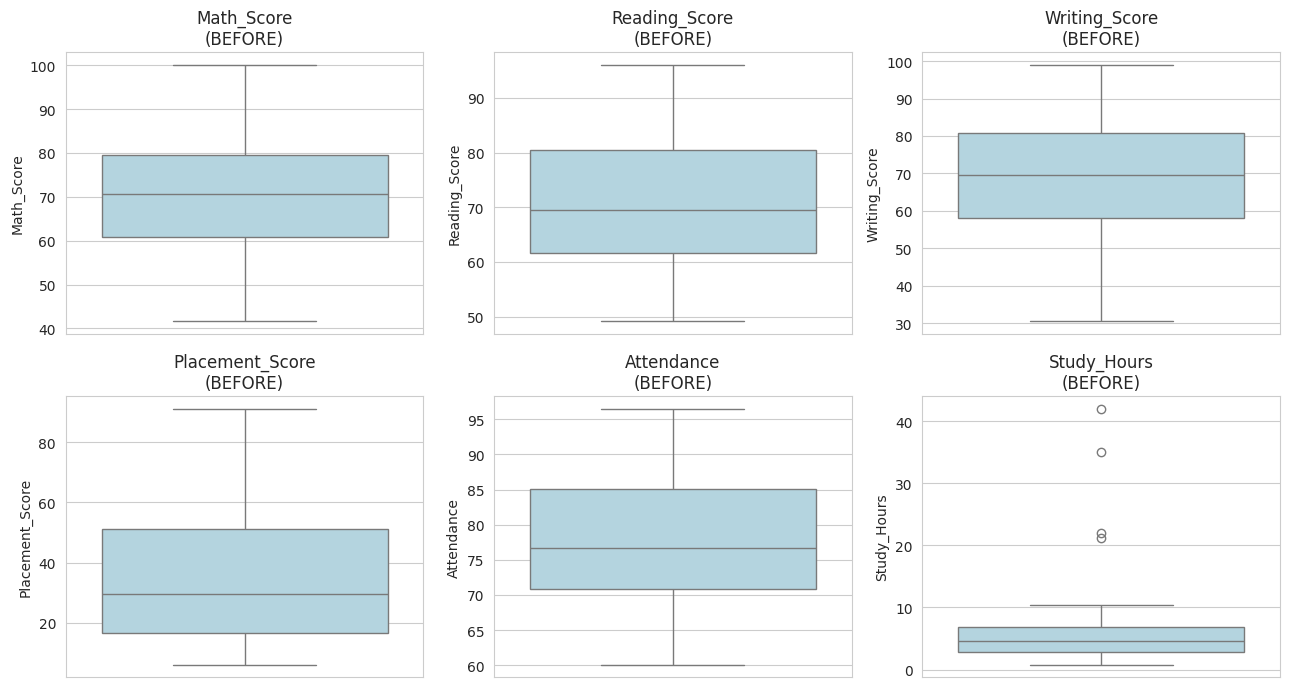

In [12]:
numeric_cols = ['Math_Score', 'Reading_Score', 'Writing_Score',
                'Placement_Score', 'Attendance', 'Study_Hours']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(f'{col}\n(BEFORE)')

plt.tight_layout()
plt.show()

### 4.2 Detect Outliers Numerically (IQR Method)

In [13]:
def detect_outliers(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f"  {name:<18} bounds=[{lower:.2f}, {upper:.2f}]  outliers = {len(outliers)}")
    return outliers

print("Outlier counts per numeric column:")
for col in numeric_cols:
    detect_outliers(df[col], col)

Outlier counts per numeric column:
  Math_Score         bounds=[32.85, 107.45]  outliers = 0
  Reading_Score      bounds=[33.41, 108.71]  outliers = 0
  Writing_Score      bounds=[24.29, 114.79]  outliers = 0
  Placement_Score    bounds=[-35.48, 103.33]  outliers = 0
  Attendance         bounds=[49.46, 106.36]  outliers = 0
  Study_Hours        bounds=[-3.23, 12.97]  outliers = 4


### 4.3 Cap Outliers (Winsorization)

In [14]:
def cap_outliers(series):
    """Replace values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR] with the boundary values."""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

# Apply capping to all numeric columns
for col in numeric_cols:
    df[col] = cap_outliers(df[col])

print("After capping, outlier counts:")
for col in numeric_cols:
    detect_outliers(df[col], col)

After capping, outlier counts:
  Math_Score         bounds=[32.85, 107.45]  outliers = 0
  Reading_Score      bounds=[33.41, 108.71]  outliers = 0
  Writing_Score      bounds=[24.29, 114.79]  outliers = 0
  Placement_Score    bounds=[-35.48, 103.33]  outliers = 0
  Attendance         bounds=[49.46, 106.36]  outliers = 0
  Study_Hours        bounds=[-3.23, 12.97]  outliers = 0


### 4.4 Boxplots AFTER Treatment

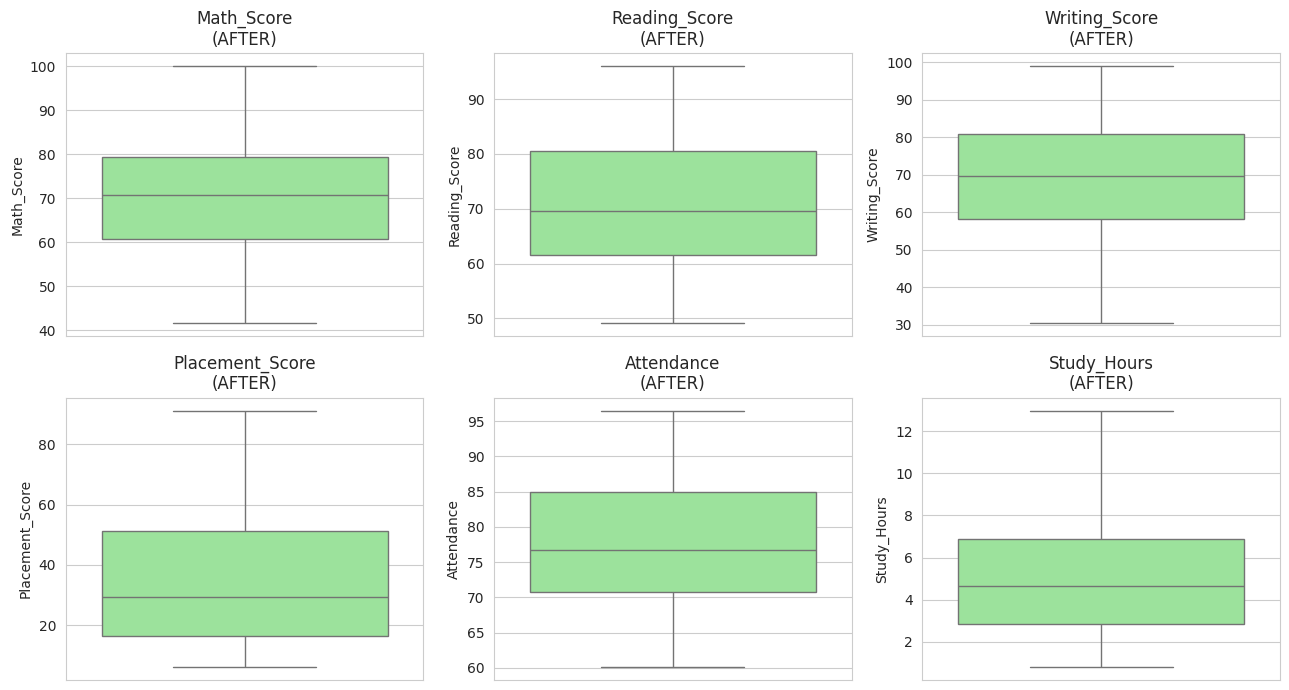

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col}\n(AFTER)')

plt.tight_layout()
plt.show()

## Operation 3 — Data Transformation

We apply a **log transformation** to `Study_Hours` because study time is typically right-skewed — a few students study very long hours.

**Why?** Many statistical methods assume normally distributed data. Log-transforming reduces skewness, making the distribution more bell-shaped.

**How?** `np.log1p(x) = log(1 + x)` — handles zero values safely (since `log(0)` is undefined).

### 5.1 Check Skewness Before Transformation

In [16]:
# .skew() returns a number describing distribution asymmetry:
#   skew == 0  -> symmetric (normal)
#   skew  > 0  -> right-skewed (tail on right)
#   skew  < 0  -> left-skewed
print("Skewness of numeric variables:")
for col in numeric_cols:
    print(f"  {col:<18}: {df[col].skew():.4f}")

Skewness of numeric variables:
  Math_Score        : -0.0229
  Reading_Score     : 0.1431
  Writing_Score     : -0.0973
  Placement_Score   : 0.7638
  Attendance        : 0.2233
  Study_Hours       : 0.9339


### 5.2 Original Study_Hours Distribution

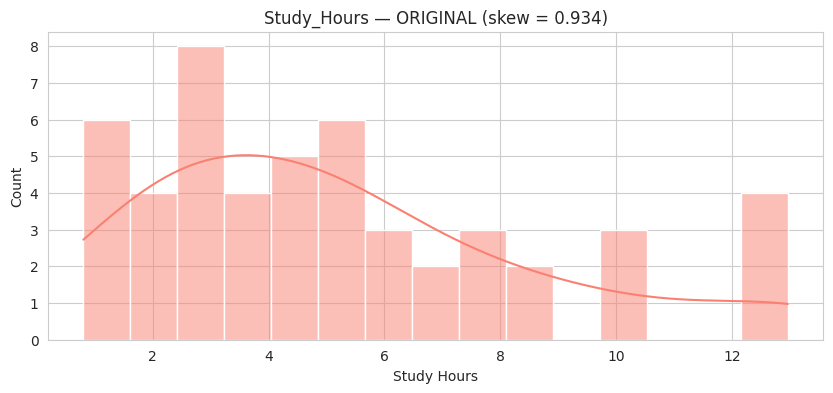

In [17]:
plt.figure(figsize=(10, 4))
sns.histplot(df['Study_Hours'], kde=True, color='salmon', bins=15)
plt.title(f"Study_Hours — ORIGINAL (skew = {df['Study_Hours'].skew():.3f})")
plt.xlabel('Study Hours')
plt.show()

### 5.3 Apply Log Transformation

In [18]:
# log1p(x) = log(1 + x); safe for zero values
df['Study_Hours_log'] = np.log1p(df['Study_Hours'])

print(f"Skewness BEFORE log: {df['Study_Hours'].skew():.4f}")
print(f"Skewness AFTER  log: {df['Study_Hours_log'].skew():.4f}")
print(f"\nSkewness moved closer to 0 — distribution is more symmetric.")

Skewness BEFORE log: 0.9339
Skewness AFTER  log: -0.0860

Skewness moved closer to 0 — distribution is more symmetric.


### 5.4 Compare Distributions Before vs After

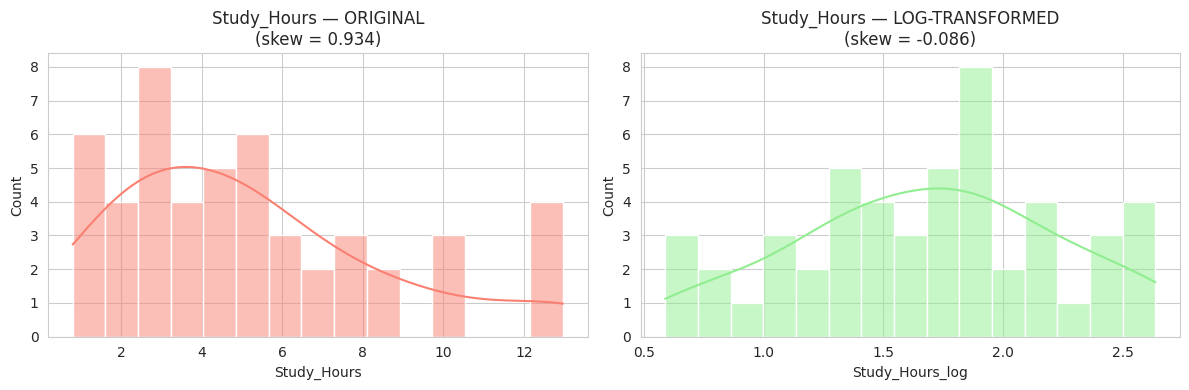

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Study_Hours'], kde=True, color='salmon', ax=ax[0], bins=15)
ax[0].set_title(f"Study_Hours — ORIGINAL\n(skew = {df['Study_Hours'].skew():.3f})")

sns.histplot(df['Study_Hours_log'], kde=True, color='lightgreen', ax=ax[1], bins=15)
ax[1].set_title(f"Study_Hours — LOG-TRANSFORMED\n(skew = {df['Study_Hours_log'].skew():.3f})")

plt.tight_layout()
plt.show()

### 5.5 Other Transformations (For Reference)

In [20]:
# Demonstrate three more techniques on Study_Hours

# Square root — milder than log
df['Study_Hours_sqrt'] = np.sqrt(df['Study_Hours'])

# Min-Max scaling — rescales values to [0, 1]
df['Study_Hours_minmax'] = (df['Study_Hours'] - df['Study_Hours'].min()) / \
                            (df['Study_Hours'].max() - df['Study_Hours'].min())

# Z-score (Standardization) — centers on 0 with std = 1
df['Study_Hours_zscore'] = (df['Study_Hours'] - df['Study_Hours'].mean()) / df['Study_Hours'].std()

# Compare skewness across all transformations
comparison = pd.DataFrame({
    'Original': [df['Study_Hours'].skew()],
    'Log':      [df['Study_Hours_log'].skew()],
    'Sqrt':     [df['Study_Hours_sqrt'].skew()],
    'Min-Max':  [df['Study_Hours_minmax'].skew()],
    'Z-score':  [df['Study_Hours_zscore'].skew()],
}, index=['Skewness']).round(4)

print("Skewness comparison across transformations:")
comparison

Skewness comparison across transformations:


,Original,Log,Sqrt,Min-Max,Z-score
Skewness,0.9339,-0.086,0.3168,0.9339,0.9339


## Step 6: Final Cleaned and Transformed DataFrame

In [21]:
print("Final shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
print("\nFinal columns:")
print(df.columns.tolist())
print("\nPreview:")
df.head(10)

Final shape: (50, 15)

Missing values: 0

Final columns:
['Roll_No', 'Name', 'Gender', 'Age', 'Class', 'Math_Score', 'Reading_Score', 'Writing_Score', 'Placement_Score', 'Attendance', 'Study_Hours', 'Study_Hours_log', 'Study_Hours_sqrt', 'Study_Hours_minmax', 'Study_Hours_zscore']

Preview:


,Roll_No,Name,Gender,Age,Class,Math_Score,Reading_Score,Writing_Score,Placement_Score,Attendance,Study_Hours,Study_Hours_log,Study_Hours_sqrt,Study_Hours_minmax,Study_Hours_zscore
0,1,Student_001,Male,20.0,TY,78.80,77.3,51.8,9.6,84.8,4.5700,1.717395,2.137756,0.309842,-0.193356
1,2,Student_002,Female,20.0,SY,69.40,77.8,89.1,39.6,76.2,8.1200,2.210470,2.849561,0.601603,0.857493
2,3,Student_003,Male,18.0,TY,45.40,80.1,71.7,42.9,76.7,1.3600,0.858662,1.166190,0.046024,-1.143561
3,4,Student_004,Female,19.0,BE,70.75,82.4,76.2,37.6,64.1,5.1600,1.818077,2.271563,0.358332,-0.018708
4,5,Student_005,Female,18.0,TY,54.00,55.7,66.1,21.5,67.9,5.9000,1.931521,2.428992,0.419149,0.200342
5,6,Student_006,Female,19.0,SY,60.80,65.9,72.1,80.5,73.0,5.8000,1.916923,2.408319,0.410931,0.170741
6,7,Student_007,Female,21.0,TY,79.70,49.2,81.1,7.3,68.7,12.9675,2.636733,3.601042,1.000000,2.292421
7,8,Student_008,Female,17.0,BE,70.75,81.0,54.1,13.3,83.8,5.9500,1.938742,2.439262,0.423259,0.215143
8,9,Student_009,Female,22.0,TY,71.40,69.5,71.7,29.5,61.5,4.2300,1.654411,2.056696,0.281899,-0.294001
9,10,Student_010,Female,20.0,SY,54.80,77.2,77.7,50.4,66.7,3.0200,1.391282,1.737815,0.182453,-0.652178


## Conclusion

We performed three data-wrangling operations on the academic performance dataset:

1. **Missing values & inconsistencies**
   - Counted NaNs with `isnull().sum()`
   - Standardized 8 different gender label spellings (`M`, `Male`, `male`, `MALE`, etc.) into clean `Male`/`Female`
   - Flagged out-of-range values as NaN (negative ages, attendance > 100%, scores > 100)
   - Filled all numeric NaN values with column **median** (robust to outliers)

2. **Outliers**
   - Visualized with **boxplots** before/after
   - Detected numerically using the **IQR rule** (Q1 − 1.5·IQR, Q3 + 1.5·IQR)
   - Treated via **winsorization** — capping outliers at IQR boundaries

3. **Transformation**
   - Applied `log1p()` to `Study_Hours` to reduce its right-skewness
   - Verified skewness decreased toward zero
   - Demonstrated sqrt, Min-Max, and Z-score scaling for completeness

The final DataFrame has no missing values, no extreme outliers, and a more symmetric `Study_Hours` distribution — ready for downstream analysis or modeling.

## Explanation of Everything Used in This Notebook

### Libraries

| Library | Purpose |
|---------|---------|
| **pandas** | DataFrame operations, reading CSVs, statistics |
| **numpy** | Numerical computing — `np.nan`, `log1p`, `sqrt`, mathematical operations |
| **matplotlib.pyplot** | Base plotting — figure size, titles, axes |
| **seaborn** | Statistical visualization — cleaner boxplots, histograms, heatmaps |

### Functions and Methods Used

#### Data Loading & Inspection
- `pd.read_csv(path)` — read CSV into DataFrame
- `df.shape`, `df.head()`, `df.info()`, `df.describe()` — inspection methods
- `df.dtypes` — column data types
- `df.select_dtypes(include='number')` — select only numeric columns

#### Missing Value Handling
- `df.isnull()` — boolean mask; True where NaN
- `.sum()` — counts True values
- `df['col'].fillna(value)` — replace NaN
- `df['col'].median()` — middle value, robust to outliers
- `df.loc[condition, 'col'] = value` — conditional assignment

#### String Cleaning
- `.str.strip()` — removes whitespace
- `.str.lower()` — converts to lowercase
- `.map({old: new})` — replaces values via dictionary

#### Outlier Detection & Treatment
- `df['col'].quantile(0.25)`, `df['col'].quantile(0.75)` — Q1 and Q3
- **IQR rule** — outlier if value < Q1 − 1.5·IQR or > Q3 + 1.5·IQR
- `series.clip(lower, upper)` — caps values to [lower, upper] range

#### Transformations
- `np.log1p(x)` — `log(1 + x)`; safe for zero values
- `np.sqrt(x)` — square root
- **Min-Max scaling** — `(x − min)/(max − min)` rescales to [0, 1]
- **Z-score (Standardization)** — `(x − mean)/std` centers on 0 with std = 1
- `df['col'].skew()` — distribution asymmetry

#### Visualization
- `sns.boxplot(y=...)` — box-and-whisker plot
- `sns.histplot(x, kde=True, bins=N)` — histogram with smooth density curve
- `sns.heatmap(matrix, cbar=False, cmap='viridis')` — colored grid
- `plt.subplots(rows, cols, figsize=(w, h))` — grid of plots
- `plt.tight_layout()` — prevents overlap
- `plt.show()` — render the figure

### Key Concepts

#### Median Imputation
Filling missing values with the column's median. Robust to outliers — chosen over mean because mean is dragged by extreme values.

#### IQR Rule
The **Interquartile Range** is the spread of the middle 50% of data: IQR = Q3 − Q1. Tukey's rule defines a value as an outlier if it lies more than 1.5×IQR below Q1 or above Q3.

#### Winsorization (Capping)
Replacing outliers with the IQR boundary instead of dropping them. Preserves all rows.

#### Skewness
A number describing distribution asymmetry:
- **0** → symmetric (bell-shaped)
- **> 0** → right-skewed (long tail on right; mean > median)
- **< 0** → left-skewed (long tail on left; mean < median)

#### Log Transformation
Applying `log()` (or `log1p()`) to a right-skewed variable to compress the long tail.

#### Why `log1p` not `log`?
`log(0)` is undefined (−∞). `log1p(x) = log(1 + x)` returns 0 for input 0 — safe for any non-negative data including zeros.

#### Min-Max Scaling vs Standardization
- **Min-Max** — rescales to [0, 1] via `(x − min)/(max − min)`. Preserves shape.
- **Standardization (Z-score)** — transforms to mean 0, std 1 via `(x − mean)/std`. Better for normal data.

## Viva Questions (with Answers)

**Q1. What is data wrangling?**
The process of cleaning and preparing raw data for analysis — handling missing values, inconsistencies, outliers, and applying transformations. Typically takes 60–80% of any data science project.

**Q2. Why standardize gender labels?**
ML models treat each unique string as a separate category. So `'M'`, `'Male'`, `'male'`, `'MALE'` would be 4 separate genders, fragmenting information.

**Q3. Why use median instead of mean for imputation?**
Median is **robust to outliers**; mean is dragged by extreme values. With messy real-world data, median is safer.

**Q4. What is the IQR method for outlier detection?**
Compute Q1 (25th percentile) and Q3 (75th percentile). IQR = Q3 − Q1. A value is an outlier if it's below Q1 − 1.5·IQR or above Q3 + 1.5·IQR.

**Q5. What is winsorization?**
Capping outliers at the IQR boundary instead of removing rows. Preserves all data points.

**Q6. Why cap rather than drop outliers in this dataset?**
- Preserves all 50 rows (small dataset)
- Outliers might be real students with unusual study habits
- Dropping loses information

**Q7. What is skewness?**
A number describing distribution asymmetry. Zero = symmetric. Positive = right-skewed (tail on right). Negative = left-skewed.

**Q8. Why log-transform Study_Hours?**
Study hours are typically right-skewed (most students study moderate amounts; a few study very long hours). Log makes the distribution more normal, which many statistical methods require.

**Q9. Why use `np.log1p()` instead of `np.log()`?**
`log(0)` is undefined. `log1p(x) = log(1+x)` handles zero values safely — `log1p(0) = log(1) = 0`.

**Q10. What's the difference between Min-Max scaling and Standardization?**
- **Min-Max**: rescales to [0, 1] via `(x − min)/(max − min)` — preserves shape
- **Z-score**: centers on 0 with std = 1 via `(x − mean)/std` — better for normally distributed data

**Q11. What does the box in a boxplot show?**
The middle 50% of the data — from Q1 (bottom) to Q3 (top). The line inside is the median.

**Q12. What are whiskers in a boxplot?**
Lines extending from the box to the smallest and largest values within 1.5×IQR. Anything beyond is shown as outlier dots.

**Q13. What does `.clip(lower, upper)` do?**
Replaces values below `lower` with `lower`, and values above `upper` with `upper`. Middle range unchanged.

**Q14. What's `df.select_dtypes(include='number')` for?**
Selects only numeric columns from the DataFrame, useful for applying numeric-only operations.

**Q15. Why don't we cap the categorical/Roll_No columns?**
They're identifiers and labels — capping makes no sense for non-continuous data.

**Q16. What does `pd.read_csv` do?**
Reads a comma-separated file into a pandas DataFrame.

**Q17. What's the purpose of `df['col'] = df['col'].fillna(...)` over `df['col'].fillna(..., inplace=True)`?**
Modern pandas (3.x) has Copy-on-Write — chained `inplace=True` may silently fail. Assignment style always works.

**Q18. What other transformations exist besides log?**
- Square root (mild skew)
- Reciprocal (1/x; strong skew correction)
- Box-Cox (auto-picks best power)
- Yeo-Johnson (handles negative values)
- Min-Max scaling
- Standardization (Z-score)

**Q19. What's the purpose of the gender map dictionary?**
To collapse 8 different spellings into 2 standardized labels: `Male` and `Female`.

**Q20. How would you handle missing values for the Gender column?**
Use the **mode** (most frequent value) instead of median:
`df['Gender'].fillna(df['Gender'].mode()[0])`.